In [ ]:
import kagglehub

resume_path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to resume dataset files:", resume_path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to resume dataset files: /kaggle/input/resume-dataset


In [ ]:
import os

# List contents of the downloaded resume dataset
print(os.listdir(resume_path))

# Assuming there's a main folder inside, let's explore one level deeper if necessary
# For example, if os.listdir(resume_path) shows ['resume_dataset_folder'], then:
# print(os.listdir(os.path.join(resume_path, 'resume_dataset_folder')))



['Resume', 'data']


In [ ]:
import os

# Explore the 'Resume' folder
resume_files = os.listdir(os.path.join(resume_path, 'Resume'))
print(f"Contents of 'Resume' folder: {resume_files[:5]}... (showing first 5)") # Print only a few for brevity

# Also check the 'data' folder for annotations/metadata
data_files = os.listdir(os.path.join(resume_path, 'data'))
print(f"Contents of 'data' folder: {data_files[:5]}... (showing first 5)") # Print only a few for brevity

# If it's a nested structure, we might need to go deeper
# For example, if resume_files contains subfolders, we'd explore one of them.
# Let's assume for now that 'Resume' directly contains the files we need.


Contents of 'Resume' folder: ['Resume.csv']... (showing first 5)
Contents of 'data' folder: ['data']... (showing first 5)


In [ ]:
import pandas as pd
import os

resume_csv_path = os.path.join(resume_path, 'Resume', 'Resume.csv')
resume_df = pd.read_csv(resume_csv_path)

print("Shape of the DataFrame:", resume_df.shape)
print("\nColumns in the DataFrame:", resume_df.columns.tolist())
print("\nFirst 5 rows of the DataFrame:")
print(resume_df.head())

# Check the 'data' folder for other potentially relevant files
data_subfolder_path = os.path.join(resume_path, 'data', 'data')
if os.path.exists(data_subfolder_path):
    print(f"\nContents of {data_subfolder_path}: {os.listdir(data_subfolder_path)[:5]}... (showing first 5)")


Shape of the DataFrame: (2484, 4)

Columns in the DataFrame: ['ID', 'Resume_str', 'Resume_html', 'Category']

First 5 rows of the DataFrame:
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  

Contents of /kaggle/input/resume-dataset/data/data: ['DESIGNER', 'BPO', 'FINA

In [ ]:
prompt = """
Extract the following information from the given resume text.

Information to be extracted:
- **Name**: The full name of the applicant.
- **Email**: The email address of the applicant.
- **Phone**: The phone number of the applicant.
- **Skills**: A list of key technical or professional skills.
- **Education**: A list of educational qualifications, including degree, major, and institution.
- **Experience**: A list of work experiences, including job title, company, and duration.

Always give your response in the following JSON format:
{
    "name": "FULL_NAME",
    "email": "EMAIL_ADDRESS",
    "phone": "PHONE_NUMBER",
    "skills": ["SKILL1", "SKILL2"],
    "education": [
        {
            "degree": "DEGREE_NAME",
            "major": "MAJOR_NAME",
            "institution": "INSTITUTION_NAME"
        }
    ],
    "experience": [
        {
            "title": "JOB_TITLE",
            "company": "COMPANY_NAME",
            "duration": "JOB_DURATION_E.G._MONTHS_YEARS",
            "description": "JOB_DESCRIPTION_SUMMARY"
        }
    ]
}

If any information is not found, use an empty string for single values or an empty list for list values. Do not generate additional text or explanations outside the JSON block.

Here is the resume text:

"""

In [ ]:
from google import genai
from google.colab import userdata
import json
import time
import os

genai_client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

output_folder_path_resume = "/content/json_output_resumes"

if not os.path.exists(output_folder_path_resume):
  os.makedirs(output_folder_path_resume)
  print(f"Created folder: {output_folder_path_resume}")

print(f"Total resumes in DataFrame: {len(resume_df)}")

start_time = time.time()

for i, row in resume_df.head(20).iterrows(): # Processing first 20 resumes
  resume_id = row['ID']
  resume_text = row['Resume_str']

  print(f"\nProcessing resume ID: {resume_id}")

  current_prompt = prompt + resume_text

  try:
    contents = [
      {
        "text": current_prompt
      }
    ]
    response = genai_client.models.generate_content(model='gemini-2.5-flash', contents=contents)

    # Access the usage_metadata attribute
    usage_metadata = response.usage_metadata

    # Print the different token counts
    print(f"Input Token Count: {usage_metadata.prompt_token_count}")
    print(f"Thoughts Token Count: {response.usage_metadata.thoughts_token_count}")
    print(f"Output Token Count: {usage_metadata.candidates_token_count}")
    print(f"Total Token Count: {usage_metadata.total_token_count}")

    # Clean and parse JSON
    extracted_information = json.loads(response.text.replace('```json', '').replace('```', ''))

    output_path = os.path.join(output_folder_path_resume, f"resume_{resume_id}.json")
    with open(output_path, "w") as f:
      json.dump(extracted_information, f, indent=4)

    print(f"Saved extracted information to {output_path}")

  except Exception as e:
    print(f"Error processing resume {resume_id}: {e}")

  print("-"*50)
  time.sleep(1) # Add a small delay to avoid hitting API rate limits

print("Information Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")


Created folder: /content/json_output_resumes
Total resumes in DataFrame: 2484

Processing resume ID: 16852973
Input Token Count: 1382
Thoughts Token Count: 1881
Output Token Count: 1130
Total Token Count: 4393
Saved extracted information to /content/json_output_resumes/resume_16852973.json
--------------------------------------------------

Processing resume ID: 22323967
Input Token Count: 1418
Thoughts Token Count: 1852
Output Token Count: 1212
Total Token Count: 4482
Saved extracted information to /content/json_output_resumes/resume_22323967.json
--------------------------------------------------

Processing resume ID: 33176873
Input Token Count: 1860
Thoughts Token Count: 1889
Output Token Count: 1089
Total Token Count: 4838
Saved extracted information to /content/json_output_resumes/resume_33176873.json
--------------------------------------------------

Processing resume ID: 27018550
Input Token Count: 878
Thoughts Token Count: 1624
Output Token Count: 513
Total Token Count: 3015


In [ ]:
import json
import os

# Get the list of generated JSON files
json_files = os.listdir('/content/json_output_resumes')

# Assuming there's at least one file, pick the first one
if json_files:
    sample_json_path = os.path.join('/content/json_output_resumes', json_files[0])

    with open(sample_json_path, 'r') as f:
        extracted_data = json.load(f)

    print(f"Content of {json_files[0]}:\n")
    print(json.dumps(extracted_data, indent=4))
else:
    print("No JSON files found in /content/json_output_resumes")


Content of resume_27490876.json:

{
    "name": "",
    "email": "",
    "phone": "",
    "skills": [
        "administrative",
        "ad",
        "arbitration",
        "agency",
        "budget",
        "Consultant",
        "database",
        "Employee Relations",
        "hiring",
        "HRIS",
        "Human Resource",
        "human resources",
        "HR",
        "team building",
        "Leadership",
        "materials",
        "meetings",
        "newsletter",
        "organizational",
        "performance management",
        "personnel",
        "presentations",
        "processes",
        "recruiting",
        "recruitment",
        "reporting",
        "staffing",
        "teacher"
    ],
    "education": [
        {
            "degree": "MBA",
            "major": "Human Resources Management",
            "institution": "University of Phoenix"
        },
        {
            "degree": "BS",
            "major": "Secondary Education",
            "institution"

In [ ]:
from google import genai
from google.colab import userdata
import json
import time
import os

genai_client = None # Initialize genai_client to None

try:
    genai_client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))
except Exception as e:
    print(f"Error retrieving GOOGLE_API_KEY: {e}")
    print("Please ensure your GOOGLE_API_KEY is set in Colab secrets with 'Notebook access' enabled.")
    print("Instructions: Go to the left-hand panel > Secrets (key icon) > + New secret. Set Name as GOOGLE_API_KEY and paste your key as Value.")
    # Do not exit here; let the rest of the script handle the absence of genai_client

output_folder_path_resume = "/content/json_output_resumes"

if not os.path.exists(output_folder_path_resume):
  os.makedirs(output_folder_path_resume)
  print(f"Created folder: {output_folder_path_resume}")

print(f"Total resumes in DataFrame: {len(resume_df)}")

start_time = time.time()

# Only proceed if genai_client was successfully initialized
if genai_client:
    for i, row in resume_df.head(20).iterrows(): # Processing first 20 resumes
      resume_id = row['ID']
      resume_text = row['Resume_str']

      print(f"\nProcessing resume ID: {resume_id}")

      current_prompt = prompt + resume_text

      try:
        contents = [
          {
            "text": current_prompt
          }
        ]
        response = genai_client.models.generate_content(model='gemini-2.5-flash', contents=contents)

        # Access the usage_metadata attribute
        usage_metadata = response.usage_metadata

        # Print the different token counts
        print(f"Input Token Count: {usage_metadata.prompt_token_count}")
        print(f"Thoughts Token Count: {response.usage_metadata.thoughts_token_count}")
        print(f"Output Token Count: {usage_metadata.candidates_token_count}")
        print(f"Total Token Count: {usage_metadata.total_token_count}")

        # Clean and parse JSON
        extracted_information = json.loads(response.text.replace('```json', '').replace('```', ''))

        output_path = os.path.join(output_folder_path_resume, f"resume_{resume_id}.json")
        with open(output_path, "w") as f:
          json.dump(extracted_information, f, indent=4)

        print(f"Saved extracted information to {output_path}")

      except Exception as e:
        print(f"Error processing resume {resume_id}: {e}")

      print("-"*50)
      time.sleep(1) # Add a small delay to avoid hitting API rate limits

    print("Information Extraction Completed.")
    print(f"Total time taken: {time.time() - start_time} seconds")
else:
    print("Skipping resume processing due to uninitialized genai_client. Please fix the API key issue.")


Total resumes in DataFrame: 2484

Processing resume ID: 16852973
Input Token Count: 1382
Thoughts Token Count: 1761
Output Token Count: 1129
Total Token Count: 4272
Saved extracted information to /content/json_output_resumes/resume_16852973.json
--------------------------------------------------

Processing resume ID: 22323967
Input Token Count: 1418
Thoughts Token Count: 2400
Output Token Count: 1250
Total Token Count: 5068
Saved extracted information to /content/json_output_resumes/resume_22323967.json
--------------------------------------------------

Processing resume ID: 33176873
Input Token Count: 1860
Thoughts Token Count: 1866
Output Token Count: 1096
Total Token Count: 4822
Saved extracted information to /content/json_output_resumes/resume_33176873.json
--------------------------------------------------

Processing resume ID: 27018550
Input Token Count: 878
Thoughts Token Count: 830
Output Token Count: 606
Total Token Count: 2314
Saved extracted information to /content/json_o

In [ ]:
import pandas as pd
import json
import os

json_output_folder = "/content/json_output_resumes"
all_extracted_data = []

# Ensure the directory exists before listing its contents
if os.path.exists(json_output_folder):
    for filename in os.listdir(json_output_folder):
        if filename.endswith('.json'):
            file_path = os.path.join(json_output_folder, filename)
            try:
                with open(file_path, 'r') as f:
                    data = json.load(f)
                    all_extracted_data.append(data)
            except json.JSONDecodeError as e:
                print(f"Error decoding JSON from {filename}: {e}")

    # Convert the list of dictionaries to a pandas DataFrame
    if all_extracted_data:
        extracted_df = pd.DataFrame(all_extracted_data)
        print("Shape of the extracted DataFrame:", extracted_df.shape)
        print("\nFirst 5 rows of the extracted DataFrame:")
        display(extracted_df.head())
    else:
        print("No valid JSON files found to create DataFrame.")
else:
    print(f"Output folder '{json_output_folder}' not found. Please ensure resumes were processed and saved.")

Shape of the extracted DataFrame: (20, 6)

First 5 rows of the extracted DataFrame:


,name,email,phone,skills,education,experience
0,,,,"[administrative, ad, arbitration, agency, budg...","[{'degree': 'MBA', 'major': 'Human Resources M...","[{'title': 'HR Coordinator', 'company': 'Compa..."
1,,,,"[Administrative Skills, Agenda Preparation, FM...","[{'degree': 'Bachelor of Science', 'major': 'S...","[{'title': 'HR Manager', 'company': 'Company N..."
2,,,,"[Analytical Skills, Interpersonal Skills, Orga...","[{'degree': '', 'major': 'Human Resources Mana...","[{'title': 'HR Director', 'company': 'Company ..."
3,,,,"[Microsoft Office proficiency, Excel spreadshe...","[{'degree': 'Certification', 'major': 'ABA App...","[{'title': 'HR Generalist', 'company': 'Compan..."
4,,,,"[Management consultation, Negotiation, Outlook...","[{'degree': 'Bachelor of Arts', 'major': 'Engl...","[{'title': 'HR Specialist', 'company': 'Compan..."


In [ ]:
print(extracted_df.info())
print("\nDataFrame Description:")
display(extracted_df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        20 non-null     object
 1   email       20 non-null     object
 2   phone       20 non-null     object
 3   skills      20 non-null     object
 4   education   20 non-null     object
 5   experience  20 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB
None

DataFrame Description:


,name,email,phone,skills,education,experience
count,20,20,20,20,20,20
unique,1,1,1,20,20,20
top,,,,"[administrative, ad, arbitration, agency, budg...","[{'degree': 'MBA', 'major': 'Human Resources M...","[{'title': 'HR Coordinator', 'company': 'Compa..."
freq,20,20,20,1,1,1



20 Most Common Skills:
- HR: 8
- Leadership: 6
- processes: 6
- benefits: 6
- payroll: 6
- Employee Relations: 5
- hiring: 5
- personnel: 5
- recruiting: 5
- recruitment: 5
- Performance Management: 5
- Human Resources: 5
- Outlook: 5
- Recruitment: 5
- ADP: 5
- administrative: 4
- database: 4
- Human Resource: 4
- reporting: 4
- Project Management: 4


/tmp/ipykernel_463/1908580693.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Skill', data=most_common_skills_df, palette='viridis')


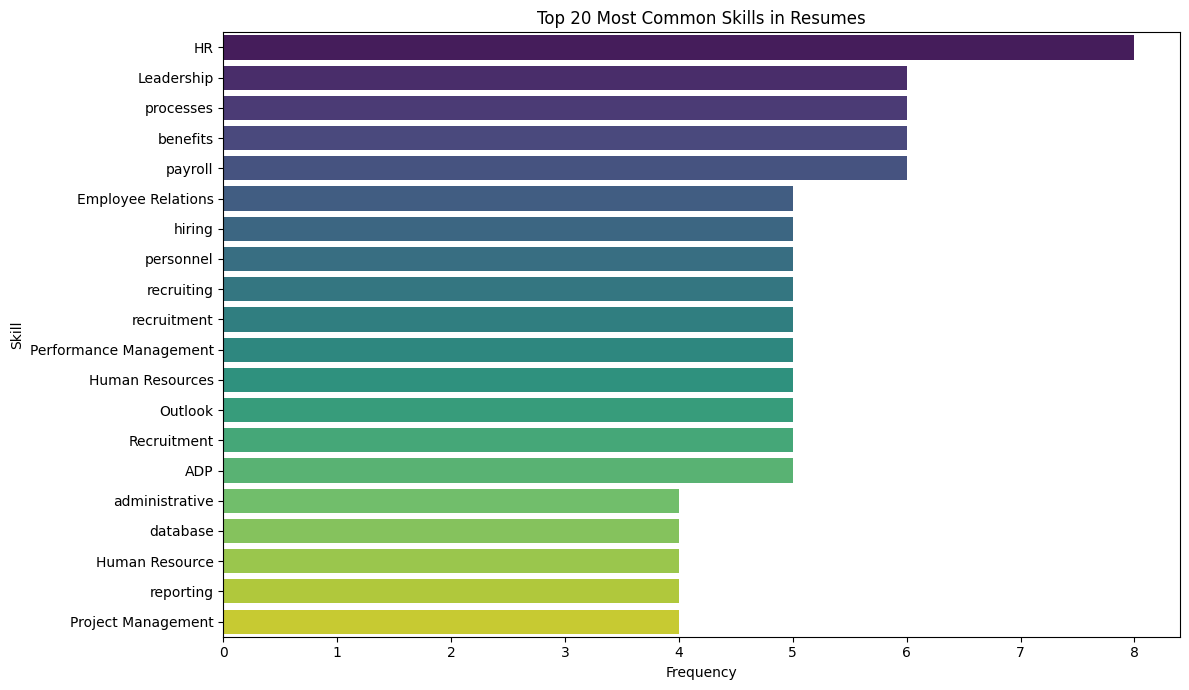

In [ ]:
from collections import Counter

# Flatten the list of skills from all resumes
all_skills = [skill for sublist in extracted_df['skills'] for skill in sublist]

# Count the frequency of each skill
skill_counts = Counter(all_skills)

# Display the 20 most common skills
print("\n20 Most Common Skills:")
for skill, count in skill_counts.most_common(20):
    print(f"- {skill}: {count}")

# You can also visualize this data if needed
import matplotlib.pyplot as plt
import seaborn as sns

most_common_skills_df = pd.DataFrame(skill_counts.most_common(20), columns=['Skill', 'Count'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Skill', data=most_common_skills_df, palette='viridis')
plt.title('Top 20 Most Common Skills in Resumes')
plt.xlabel('Frequency')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()


20 Most Common Skills:
- HR: 8
- Leadership: 6
- processes: 6
- benefits: 6
- payroll: 6
- Employee Relations: 5
- hiring: 5
- personnel: 5
- recruiting: 5
- recruitment: 5
- Performance Management: 5
- Human Resources: 5
- Outlook: 5
- Recruitment: 5
- ADP: 5
- administrative: 4
- database: 4
- Human Resource: 4
- reporting: 4
- Project Management: 4


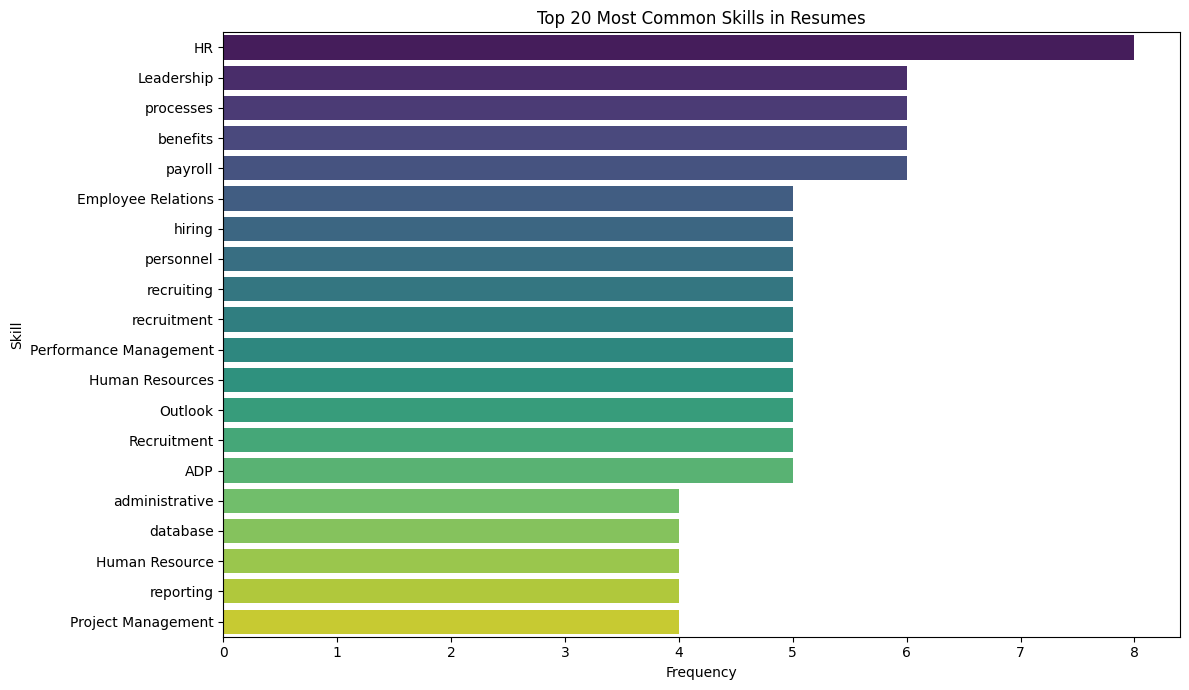

In [ ]:
from collections import Counter

# Flatten the list of skills from all resumes
all_skills = [skill for sublist in extracted_df['skills'] for skill in sublist]

# Count the frequency of each skill
skill_counts = Counter(all_skills)

# Display the 20 most common skills
print("\n20 Most Common Skills:")
for skill, count in skill_counts.most_common(20):
    print(f"- {skill}: {count}")

# You can also visualize this data if needed
import matplotlib.pyplot as plt
import seaborn as sns

most_common_skills_df = pd.DataFrame(skill_counts.most_common(20), columns=['Skill', 'Count'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Skill', data=most_common_skills_df, palette='viridis', hue='Skill', legend=False)
plt.title('Top 20 Most Common Skills in Resumes')
plt.xlabel('Frequency')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()


Most Common Degrees:
- MBA: 5
- Bachelor of Science: 3
- BS: 2
- Bachelor of Arts: 2
- Associate of Arts: 2
- SHRM Class Certificate: 1
- Program Completion: 1
- Certification: 1
- BA: 1
- AS: 1

Most Common Institutions:
- University of Phoenix: 4
- Friends University: 2
- SHRM: 2
- Walsh College: 2
- St. Petersburg College: 2
- Old Dominion University: 1
- VCU School of Business: 1
- Grace E. Harris Leadership Institute, VCU School of Business: 1
- TEXAS WOMAN'S UNIVERSITY: 1
- Webster University: 1


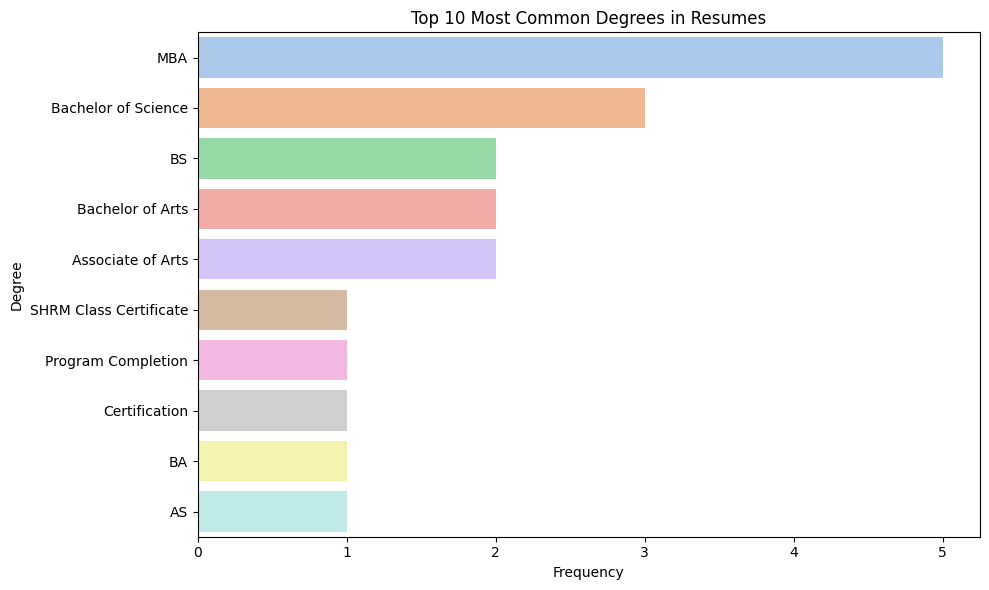

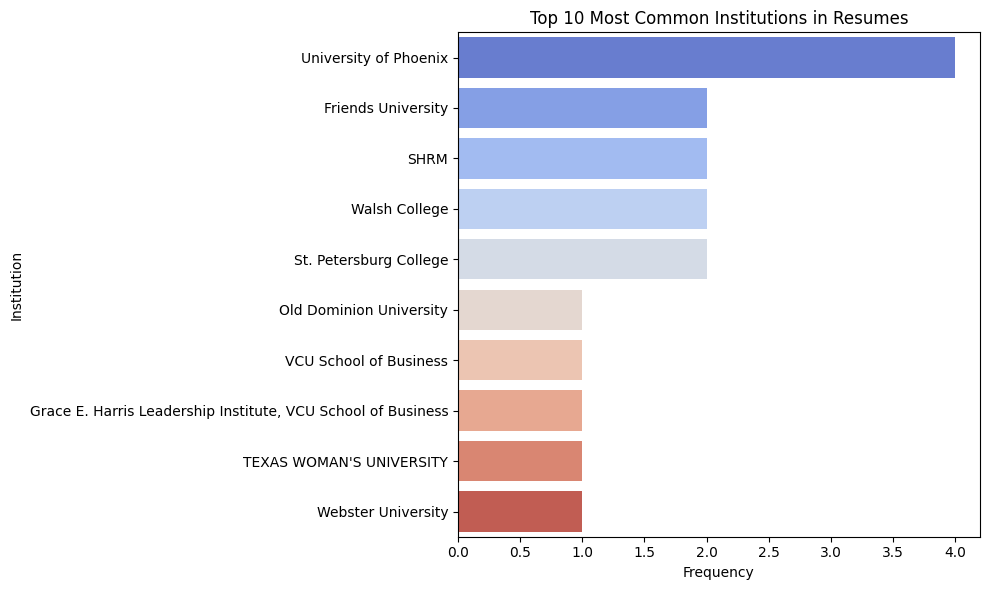

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

all_degrees = []
all_institutions = []

for edu_list in extracted_df['education']:
    for edu_entry in edu_list:
        if edu_entry.get('degree'):
            all_degrees.append(edu_entry['degree'])
        if edu_entry.get('institution'):
            all_institutions.append(edu_entry['institution'])

# Count the frequency of each degree and institution
degree_counts = Counter(all_degrees)
institution_counts = Counter(all_institutions)

print("\nMost Common Degrees:")
for degree, count in degree_counts.most_common(10):
    print(f"- {degree}: {count}")

print("\nMost Common Institutions:")
for institution, count in institution_counts.most_common(10):
    print(f"- {institution}: {count}")

# Visualize Most Common Degrees
if degree_counts:
    most_common_degrees_df = pd.DataFrame(degree_counts.most_common(10), columns=['Degree', 'Count'])
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Count', y='Degree', data=most_common_degrees_df, palette='pastel', hue='Degree', legend=False)
    plt.title('Top 10 Most Common Degrees in Resumes')
    plt.xlabel('Frequency')
    plt.ylabel('Degree')
    plt.tight_layout()
    plt.show()

# Visualize Most Common Institutions
if institution_counts:
    most_common_institutions_df = pd.DataFrame(institution_counts.most_common(10), columns=['Institution', 'Count'])
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Count', y='Institution', data=most_common_institutions_df, palette='coolwarm', hue='Institution', legend=False)
    plt.title('Top 10 Most Common Institutions in Resumes')
    plt.xlabel('Frequency')
    plt.ylabel('Institution')
    plt.tight_layout()
    plt.show()



Most Common Degrees:
- MBA: 5
- Bachelor of Science: 3
- BS: 2
- Bachelor of Arts: 2
- Associate of Arts: 2
- SHRM Class Certificate: 1
- Program Completion: 1
- Certification: 1
- BA: 1
- AS: 1

Most Common Institutions:
- University of Phoenix: 4
- Friends University: 2
- SHRM: 2
- Walsh College: 2
- St. Petersburg College: 2
- Old Dominion University: 1
- VCU School of Business: 1
- Grace E. Harris Leadership Institute, VCU School of Business: 1
- TEXAS WOMAN'S UNIVERSITY: 1
- Webster University: 1


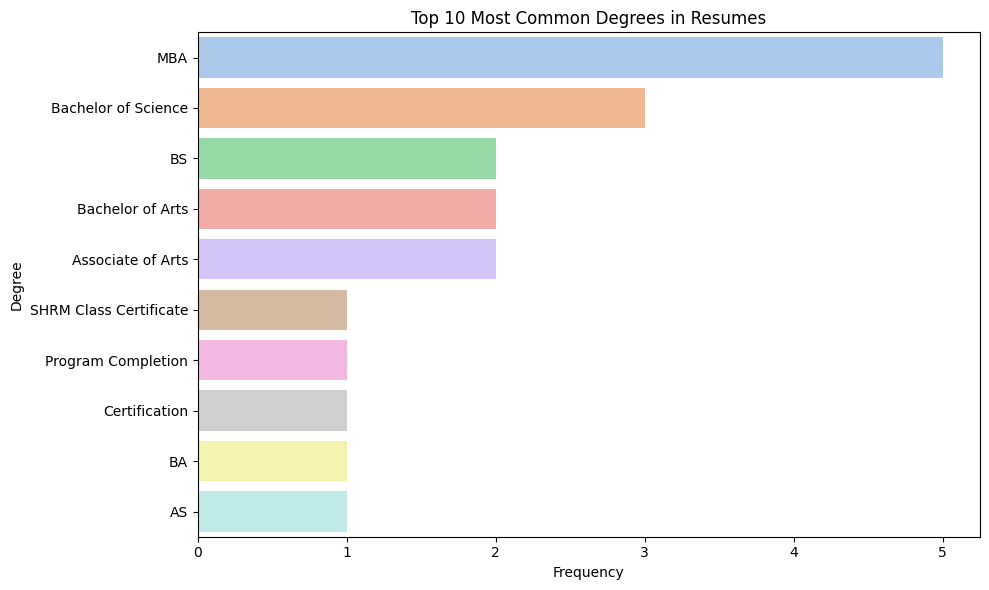

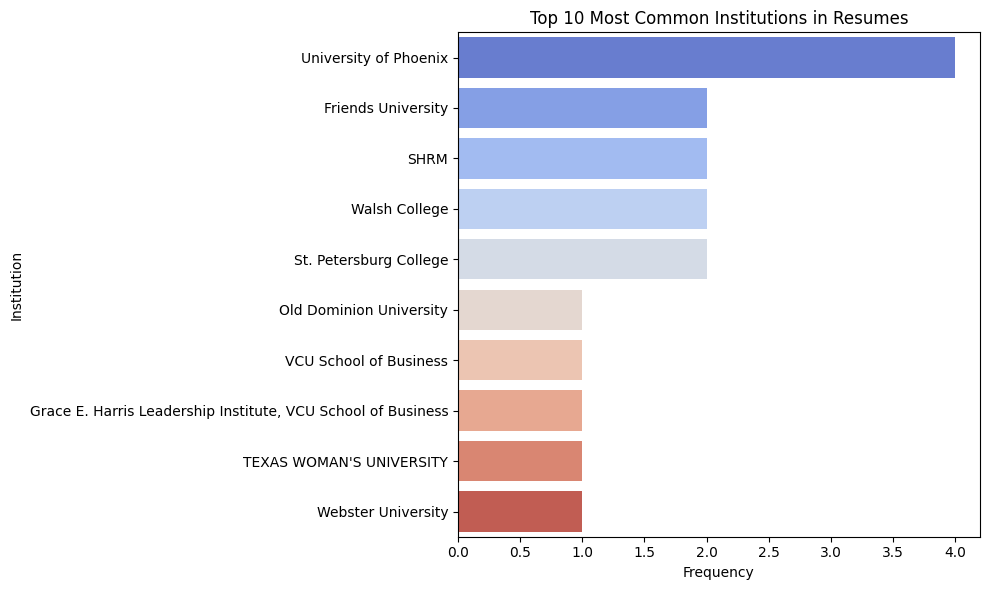

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

all_degrees = []
all_institutions = []

for edu_list in extracted_df['education']:
    for edu_entry in edu_list:
        if edu_entry.get('degree'):
            all_degrees.append(edu_entry['degree'])
        if edu_entry.get('institution'):
            all_institutions.append(edu_entry['institution'])

# Count the frequency of each degree and institution
degree_counts = Counter(all_degrees)
institution_counts = Counter(all_institutions)

print("\nMost Common Degrees:")
for degree, count in degree_counts.most_common(10):
    print(f"- {degree}: {count}")

print("\nMost Common Institutions:")
for institution, count in institution_counts.most_common(10):
    print(f"- {institution}: {count}")

# Visualize Most Common Degrees
if degree_counts:
    most_common_degrees_df = pd.DataFrame(degree_counts.most_common(10), columns=['Degree', 'Count'])
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Count', y='Degree', data=most_common_degrees_df, palette='pastel', hue='Degree', legend=False)
    plt.title('Top 10 Most Common Degrees in Resumes')
    plt.xlabel('Frequency')
    plt.ylabel('Degree')
    plt.tight_layout()
    plt.show()

# Visualize Most Common Institutions
if institution_counts:
    most_common_institutions_df = pd.DataFrame(institution_counts.most_common(10), columns=['Institution', 'Count'])
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Count', y='Institution', data=most_common_institutions_df, palette='coolwarm', hue='Institution', legend=False)
    plt.title('Top 10 Most Common Institutions in Resumes')
    plt.xlabel('Frequency')
    plt.ylabel('Institution')
    plt.tight_layout()
    plt.show()




Most Common Job Titles:
- HR Manager: 6
- HR Director: 4
- HR Coordinator: 3
- HR Generalist: 3
- HR Assistant: 3
- HR Representative: 3
- HR Analyst: 2
- Senior HR Analyst: 2
- Human Resources Coordinator: 2
- HR Clerk: 2

Most Common Companies:
- Company Name: 87
- Tipton Management- Pine Lake Village Apartments: 1
- Sunningdale Tech (Thailand) Co.,Ltd.: 1
- Sekisui s - lec ( Thailand ) Co., Ltd.: 1


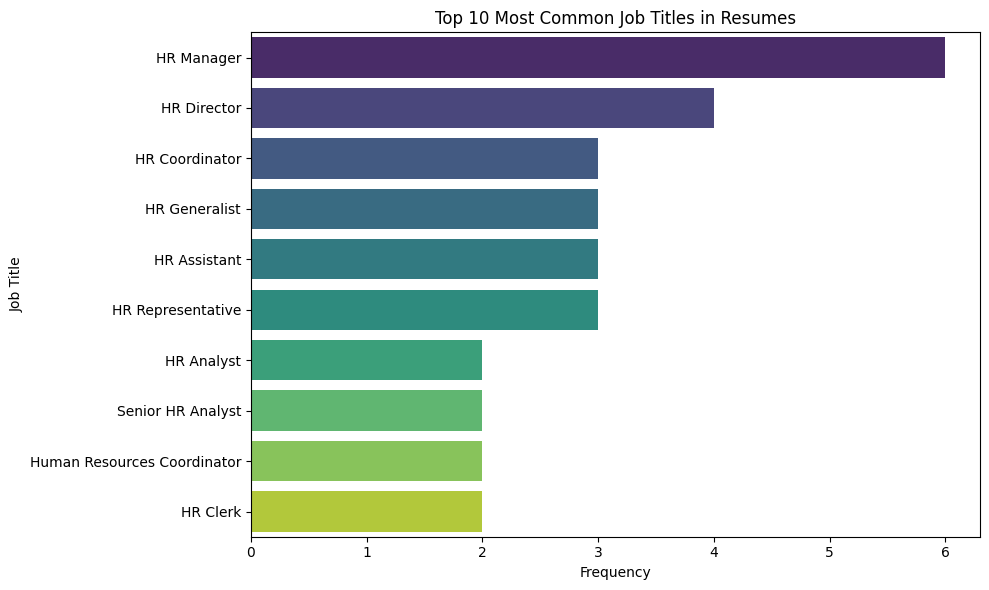

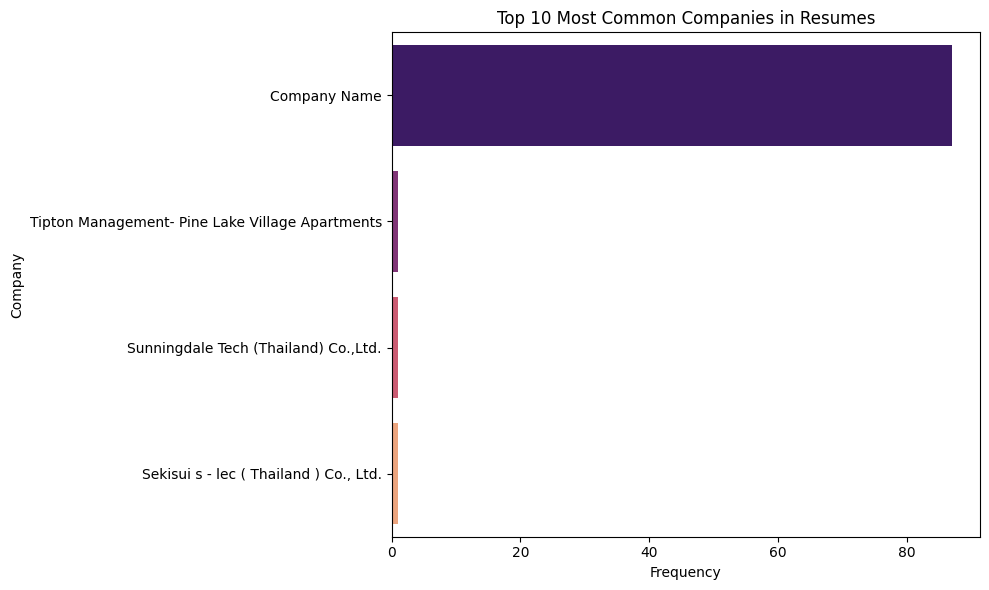

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

all_titles = []
all_companies = []

for exp_list in extracted_df['experience']:
    for exp_entry in exp_list:
        if exp_entry.get('title'):
            all_titles.append(exp_entry['title'])
        if exp_entry.get('company'):
            all_companies.append(exp_entry['company'])

# Count the frequency of each job title and company
title_counts = Counter(all_titles)
company_counts = Counter(all_companies)

print("\nMost Common Job Titles:")
for title, count in title_counts.most_common(10):
    print(f"- {title}: {count}")

print("\nMost Common Companies:")
for company, count in company_counts.most_common(10):
    print(f"- {company}: {count}")

# Visualize Most Common Job Titles
if title_counts:
    most_common_titles_df = pd.DataFrame(title_counts.most_common(10), columns=['Title', 'Count'])
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Count', y='Title', data=most_common_titles_df, palette='viridis', hue='Title', legend=False)
    plt.title('Top 10 Most Common Job Titles in Resumes')
    plt.xlabel('Frequency')
    plt.ylabel('Job Title')
    plt.tight_layout()
    plt.show()

# Visualize Most Common Companies
if company_counts:
    most_common_companies_df = pd.DataFrame(company_counts.most_common(10), columns=['Company', 'Count'])
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Count', y='Company', data=most_common_companies_df, palette='magma', hue='Company', legend=False)
    plt.title('Top 10 Most Common Companies in Resumes')
    plt.xlabel('Frequency')
    plt.ylabel('Company')
    plt.tight_layout()
    plt.show()